# FIVAR / LASSO diagnostics

Seven experiments separate factor-shock amplification from small-eigenvalue instability and evaluate covariance interventions using realized portfolio risk.

Run all cells from top to bottom in the project directory, after generating the saved inputs with `PRVM.ipynb` and `FIVAR_HAR.ipynb`. The full-sample refits and portfolio optimizations are computationally intensive. Intermediate results remain in memory; no data, model, or risk files are written.

The covariance-loss target is **same-day POET-PRVM**, whereas the main MSPE/QLIKE table in `FIVAR_HAR.ipynb` uses continuous PRVM. MSPE here is in raw units; QLIKE is multiplied by 1e-3. Portfolio evaluation uses previous-day raw jump covariance projected to PSD, as in the original portfolio experiment. These are retrospective diagnostics on the same OOS sample, not an independent validation of selected interventions.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from html import escape
import os
import cvxpy as cp
from IPython.display import SVG, display
from threadpoolctl import threadpool_limits
import math
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Keep machine-specific paths out of saved warning outputs.
def format_public_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = format_public_warning

BASE = Path.cwd().resolve()
FIVAR_DIR = BASE / 'crypto_fivar_HAR_output'
PRVM_DIR = BASE / 'crypto_prvm_output'
# The score regressions below implement VAR(1).
N, P, R, L = 365, 200, 3, 30
WORKERS = min(8, os.cpu_count() or 1)
REPRODUCTION_RTOL = 1e-8
PSD_FLOOR_RATIO = 1e-4
PSD_ABS_FLOOR = 1e-12
QLIKE_FLOOR = 1e-6
c0_values = np.linspace(1, 3, 11)
# One BLAS thread per worker prevents nested thread oversubscription.
blas_thread_limit = threadpool_limits(limits=1)


poet_all = np.load(FIVAR_DIR / 'POET_PRVM.npy', mmap_mode='r')
sparse_all = np.load(FIVAR_DIR / 'sparse_idio_PRVM.npy', mmap_mode='r')
true_poet = poet_all[N:]
dates = pd.to_datetime(pd.read_csv(PRVM_DIR / 'pred_dates_crypto_2023_2025.csv')['date'])
years = dates.dt.year.to_numpy()

prediction_paths = {
    'OLS': 'pred_OLS_crypto_threshold.npy',
    'LASSO': 'pred_LASSO_crypto_threshold.npy',
    'H-LASSO': 'pred_H_LASSO_crypto_threshold.npy',
    'POET': 'pred_POET_crypto.npy',
    'HAR-DRD-LOG': 'pred_HAR_DRD_LOG_crypto.npy',
    'EWMA': 'pred_EWMA_crypto.npy',
}
predictions = {name: np.load(FIVAR_DIR / filename, mmap_mode='r') for name, filename in prediction_paths.items()}

assert poet_all.shape == sparse_all.shape == (1095, P, P)
assert len(dates) == len(true_poet) == 730
assert all(arr.shape == true_poet.shape for arr in predictions.values())
print('Read-only inputs loaded successfully.')
print('OOS:', dates.min().date(), 'to', dates.max().date(), '| days:', len(dates))

period_masks = {
    '2024-2025': np.ones(len(dates), dtype=bool),
    '2024': years == 2024,
    '2025': years == 2025,
}
date_indices = {date.strftime('%Y-%m-%d'): i for i, date in enumerate(dates)}
assert dates.is_unique and dates.is_monotonic_increasing

risk_paths = {
    'OLS': 'risks_OLS_crypto_threshold.npy', 'LASSO': 'risks_LASSO_crypto_threshold.npy',
    'H-LASSO': 'risks_H_LASSO_crypto_threshold.npy', 'POET': 'risks_POET_crypto_threshold.npy',
    'HAR-DRD-LOG': 'risks_HAR_DRD_LOG_crypto_threshold.npy', 'EWMA': 'risks_EWMA_crypto_threshold.npy',
}
baseline_risks = {name: np.load(FIVAR_DIR / filename, mmap_mode='r') for name, filename in risk_paths.items()}
assert all(risk.shape == (len(c0_values), len(dates)) for risk in baseline_risks.values())

def annualized_risk(risk, mask):
    return np.sqrt(np.mean(np.asarray(risk)[:, mask], axis=1)) * np.sqrt(365) * 100

def build_risk_curves(risks):
    return {
        period: {label: annualized_risk(risk, mask) for label, risk in risks.items()}
        for period, mask in period_masks.items()
    }

def risk_improvement_table(curves, comparisons):
    rows = []
    for period, model_curves in curves.items():
        for variant, baseline in comparisons.items():
            for c0_index in [0, 5, 10]:
                original = model_curves[baseline][c0_index]
                modified = model_curves[variant][c0_index]
                rows.append({
                    'period': period, 'variant': variant, 'comparison': baseline,
                    'c0': c0_values[c0_index], 'baseline_risk_pct': original,
                    'modified_risk_pct': modified,
                    'relative_improvement_pct': 100 * (original - modified) / original,
                })
    return pd.DataFrame(rows)

def project_portfolio(matrix):
    matrix = 0.5 * (matrix + matrix.T)
    eig, vec = np.linalg.eigh(matrix)
    floor = max(PSD_FLOOR_RATIO * abs(np.trace(matrix)) / P, PSD_ABS_FLOOR)
    projected = (vec * np.maximum(eig, floor)) @ vec.T
    return projected, eig, floor

def qlike_single(target, pred, eps=QLIKE_FLOOR):
    eig, vec = np.linalg.eigh(0.5 * (pred + pred.T))
    eig = np.maximum(eig, eps)
    diagonal_target = np.sum(vec * (target @ vec), axis=0)
    return np.sum(np.log(eig) + diagonal_target / eig)

def qlike_series(prediction):
    return np.array([qlike_single(np.asarray(true_poet[i]), matrix) for i, matrix in enumerate(prediction)])

def make_risk_svg(curves, x_values, colors, dashed=()):
    width, height = 1500, 510
    left, top, bottom, gap = 70, 100, 55, 42
    panel_width = (width - left - 30 - 2 * gap) / 3
    plot_height = height - top - bottom
    dash = {label: '6,4' for label in dashed}
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">', '<rect width="100%" height="100%" fill="white"/>']
    for idx, label in enumerate(curves['2024-2025']):
        x = 70 + (idx % 3) * 460
        y = 22 + (idx // 3) * 24
        dash_attr = f' stroke-dasharray="{dash[label]}"' if label in dash else ''
        parts.append(f'<line x1="{x}" y1="{y}" x2="{x+28}" y2="{y}" stroke="{colors[label]}" stroke-width="3"{dash_attr}/>')
        parts.append(f'<text x="{x+35}" y="{y+5}" font-family="Arial" font-size="13">{escape(label)}</text>')
    for panel_index, (period, model_curves) in enumerate(curves.items()):
        x0 = left + panel_index * (panel_width + gap)
        all_values = np.concatenate(list(model_curves.values()))
        y_min, y_max = float(all_values.min()), float(all_values.max())
        padding = max(0.5, 0.08 * (y_max - y_min))
        y_min, y_max = y_min - padding, y_max + padding
        def xp(value): return x0 + (value - x_values.min()) / (x_values.max() - x_values.min()) * panel_width
        def yp(value): return top + (y_max - value) / (y_max - y_min) * plot_height
        parts.append(f'<text x="{x0+panel_width/2}" y="{top-10}" text-anchor="middle" font-family="Arial" font-size="18" font-weight="bold">Portfolio Risk ({period})</text>')
        for tick in np.linspace(y_min, y_max, 5):
            y = yp(tick)
            parts.append(f'<line x1="{x0}" y1="{y}" x2="{x0+panel_width}" y2="{y}" stroke="#dddddd"/>')
            parts.append(f'<text x="{x0-8}" y="{y+4}" text-anchor="end" font-family="Arial" font-size="11">{tick:.1f}</text>')
        for tick in [1.0, 1.5, 2.0, 2.5, 3.0]:
            x = xp(tick)
            parts.append(f'<line x1="{x}" y1="{top}" x2="{x}" y2="{top+plot_height}" stroke="#eeeeee"/>')
            parts.append(f'<text x="{x}" y="{top+plot_height+20}" text-anchor="middle" font-family="Arial" font-size="11">{tick:.1f}</text>')
        parts.append(f'<rect x="{x0}" y="{top}" width="{panel_width}" height="{plot_height}" fill="none" stroke="#444"/>')
        for label, values in model_curves.items():
            points = ' '.join(f'{xp(x):.1f},{yp(y):.1f}' for x, y in zip(x_values, values))
            dash_attr = f' stroke-dasharray="{dash[label]}"' if label in dash else ''
            parts.append(f'<polyline points="{points}" fill="none" stroke="{colors[label]}" stroke-width="2.5"{dash_attr}/>')
            for x, y in zip(x_values, values):
                parts.append(f'<circle cx="{xp(x):.1f}" cy="{yp(y):.1f}" r="2.5" fill="{colors[label]}"/>')
        parts.append(f'<text x="{x0+panel_width/2}" y="{height-12}" text-anchor="middle" font-family="Arial" font-size="13">Gross exposure c0</text>')
    parts.append(f'<text x="18" y="{top+plot_height/2}" transform="rotate(-90 18 {top+plot_height/2})" text-anchor="middle" font-family="Arial" font-size="13">Annualized realized risk (%)</text>')
    parts.append('</svg>')
    return ''.join(parts)

Read-only inputs loaded successfully.
OOS: 2024-01-02 to 2025-12-31 | days: 730


## Experiment 1 - Event concentration and factor-shock signature
The target is same-day POET-PRVM. Compare the mean, median, and upper tail, with and without the two selected event dates.

In [2]:
def frobenius_loss_series(pred, target, chunk=25):
    values = []
    for start in range(0, len(target), chunk):
        error = np.asarray(pred[start:start + chunk]) - np.asarray(target[start:start + chunk])
        values.extend(np.einsum('tij,tij->t', error, error))
    return np.asarray(values)

loss_series = {name: frobenius_loss_series(pred, true_poet) for name, pred in predictions.items()}

summary_rows = []
for year in [2024, 2025]:
    mask = years == year
    for name, loss in loss_series.items():
        summary_rows.append({
            'period': str(year), 'model': name, 'mean_raw': loss[mask].mean(),
            'median_raw': np.median(loss[mask]), 'q95_raw': np.quantile(loss[mask], 0.95),
        })
event_dates = {'2025-10-10', '2025-10-11'}
event_mask = dates.dt.strftime('%Y-%m-%d').isin(event_dates).to_numpy()
mask_2025_no_event = (years == 2025) & (~event_mask)
for name, loss in loss_series.items():
    summary_rows.append({
        'period': '2025 excl. Oct10-11', 'model': name, 'mean_raw': loss[mask_2025_no_event].mean(),
        'median_raw': np.median(loss[mask_2025_no_event]), 'q95_raw': np.quantile(loss[mask_2025_no_event], 0.95),
    })
summary_df = pd.DataFrame(summary_rows)
for metric in ['mean_raw', 'median_raw', 'q95_raw']:
    print(f'\n{metric}:')
    print(summary_df.pivot(index='model', columns='period', values=metric).round(6).to_string())

event_rows = []
for name in ['OLS', 'LASSO', 'H-LASSO', 'HAR-DRD-LOG']:
    loss = loss_series[name]
    total_2025 = loss[years == 2025].sum()
    event_rows.append({
        'model': name,
        'Oct10_loss': loss[(dates == pd.Timestamp('2025-10-10')).to_numpy()][0],
        'Oct11_loss': loss[(dates == pd.Timestamp('2025-10-11')).to_numpy()][0],
        'two_day_share_of_2025': loss[event_mask].sum() / total_2025,
    })
print('\nEvent concentration:')
print(pd.DataFrame(event_rows).set_index('model').round(6).to_string())
print('\nDaily loss correlation, LASSO vs OLS:', np.corrcoef(loss_series['LASSO'], loss_series['OLS'])[0, 1])

event_eigen_rows = []
for date_string in ['2025-10-10', '2025-10-11', '2025-04-14']:
    idx = date_indices[date_string]
    matrices = {'True POET': true_poet[idx], **{name: predictions[name][idx] for name in ['OLS', 'LASSO', 'H-LASSO', 'HAR-DRD-LOG']}}
    for name, matrix in matrices.items():
        eig = np.linalg.eigvalsh(0.5 * (np.asarray(matrix) + np.asarray(matrix).T))
        event_eigen_rows.append({'date': date_string, 'model': name, 'largest_eigenvalue': eig[-1], 'top3_sum': eig[-3:].sum(), 'trace': eig.sum()})
print('\nEvent spectrum:')
print(pd.DataFrame(event_eigen_rows).round(6).to_string(index=False))


mean_raw:
period           2024      2025  2025 excl. Oct10-11
model                                               
EWMA         0.115221  0.165589             0.080997
H-LASSO      0.114388  0.156390             0.068189
HAR-DRD-LOG  0.106009  0.142969             0.063600
LASSO        0.113535  1.751708             0.105476
OLS          0.113096  1.831014             0.101048
POET         0.139182  0.226183             0.090475

median_raw:
period           2024      2025  2025 excl. Oct10-11
model                                               
EWMA         0.020371  0.015147             0.014933
H-LASSO      0.014894  0.012509             0.012504
HAR-DRD-LOG  0.015564  0.014122             0.013695
LASSO        0.017348  0.019382             0.018891
OLS          0.017385  0.019214             0.019056
POET         0.022686  0.017305             0.017019

q95_raw:
period           2024      2025  2025 excl. Oct10-11
model                                               
EWMA        

## Experiment 2 - Lower-tail spectrum, QLIKE conditioning intervention, and saved portfolio risks

In [3]:
shrink_deltas = [0.001, 0.01, 0.05, 0.10]
spectrum_rows = []
qlike_rows = []
floor_counts_by_model = {}
qlike_daily = {}

for name, pred in predictions.items():
    min_eigs, q01s, q05s, conditions, counts = [], [], [], [], []
    qlike_fixed = []
    qlike_shrunk = {delta: [] for delta in shrink_deltas}
    for i in range(len(pred)):
        matrix = np.asarray(pred[i], dtype=np.float64)
        matrix = 0.5 * (matrix + matrix.T)
        eig, vec = np.linalg.eigh(matrix)
        target = np.asarray(true_poet[i], dtype=np.float64)
        target_projection = np.sum(vec * (target @ vec), axis=0)
        mean_eig = eig.mean()
        relative_floor = max(PSD_FLOOR_RATIO * abs(np.trace(matrix)) / P, PSD_ABS_FLOOR)
        min_eigs.append(eig[0])
        q01s.append(np.quantile(eig, 0.01))
        q05s.append(np.quantile(eig, 0.05))
        conditions.append(eig[-1] / max(eig[0], 1e-30))
        counts.append(np.sum(eig <= relative_floor * (1 + 1e-5) + 1e-12))
        eig_fixed = np.maximum(eig, QLIKE_FLOOR)
        qlike_fixed.append(np.sum(np.log(eig_fixed) + target_projection / eig_fixed))
        for delta in shrink_deltas:
            eig_delta = np.maximum((1 - delta) * eig + delta * mean_eig, 1e-12)
            qlike_shrunk[delta].append(np.sum(np.log(eig_delta) + target_projection / eig_delta))
    min_eigs, q01s, q05s = map(np.asarray, (min_eigs, q01s, q05s))
    conditions, counts = np.asarray(conditions), np.asarray(counts)
    floor_counts_by_model[name] = counts
    qlike_daily[name] = np.asarray(qlike_fixed)
    spectrum_rows.append({
        'model': name, 'min_eig_median': np.median(min_eigs), 'q01_median': np.median(q01s),
        'q05_median': np.median(q05s), 'condition_median': np.median(conditions),
        'condition_q95': np.quantile(conditions, 0.95), 'floor_hit_day_ratio': np.mean(counts > 0),
        'floor_count_median': np.median(counts), 'floor_count_q95': np.quantile(counts, 0.95),
    })
    row = {'model': name, 'notebook_floor_1e-6': np.mean(qlike_fixed) * 1e-3}
    row.update({f'shrink_{delta:g}': np.mean(qlike_shrunk[delta]) * 1e-3 for delta in shrink_deltas})
    qlike_rows.append(row)

spectrum_df = pd.DataFrame(spectrum_rows).set_index('model')
qlike_conditioning_df = pd.DataFrame(qlike_rows).set_index('model')
print('Spectrum diagnostics:')
print(spectrum_df.to_string(float_format=lambda x: f'{x:.6g}'))
print('\nQLIKE x 1e-3 under conditioning interventions:')
print(qlike_conditioning_df.round(6).to_string())

combined_floor = floor_counts_by_model['LASSO'] + floor_counts_by_model['H-LASSO']
floor_peak_idx = int(np.argmax(combined_floor))
print('\nLargest combined floor-hit date:', dates.iloc[floor_peak_idx].date(), '| LASSO:', floor_counts_by_model['LASSO'][floor_peak_idx], '| H-LASSO:', floor_counts_by_model['H-LASSO'][floor_peak_idx])

risk_rows = []
for name, risk in baseline_risks.items():
    annualized = annualized_risk(risk, period_masks['2024-2025'])
    risk_rows.append({'model': name, 'c0=1': annualized[0], 'c0=2': annualized[5], 'c0=3': annualized[-1], 'best': annualized.min(), 'best_c0': c0_values[annualized.argmin()]})
print('\nSaved realized portfolio risks (% annualized):')
print(pd.DataFrame(risk_rows).set_index('model').round(4).to_string())

Spectrum diagnostics:
             min_eig_median  q01_median  q05_median  condition_median  condition_q95  floor_hit_day_ratio  floor_count_median  floor_count_q95
model                                                                                                                                         
OLS             6.06687e-05 0.000143805 0.000226795           3936.43        10550.9           0.00958904                   0                0
LASSO            2.3882e-07 5.43623e-05 0.000196204       1.16128e+06    1.50588e+06             0.783562                   2                7
H-LASSO         1.92104e-07 4.30186e-05 0.000190489       1.01525e+06    1.39534e+06              0.80274                   2                7
POET            4.29692e-05 8.00008e-05 0.000125136            5402.9        17237.2                    0                   0                0
HAR-DRD-LOG     5.14357e-05 0.000122635 0.000200903           4320.16        9594.96                    0               

## Experiment 3 - Current-day versus lagged-jump regimes and POET threshold degeneracy

In [4]:
# Include the first OOS day's available previous-day observation.
# Load JV_raw once; retain the lagged PSD input for all portfolio experiments.
with np.load(PRVM_DIR / 'prvm_gamma_jv_2023_2025_top200.npz', allow_pickle=False) as archive:
    continuous_full = archive['Gamma_trunc_psd']
    continuous_trace_full = np.trace(continuous_full, axis1=1, axis2=2)
    del continuous_full
    jump_full = archive['JV_raw']
    jump_trace_full = np.trace(jump_full, axis1=1, axis2=2)
    archive_dates = pd.to_datetime(archive['days'])
assert np.array_equal(archive_dates[N:].to_numpy(), dates.to_numpy())
total_trace_full = continuous_trace_full + jump_trace_full
assert np.all(np.isfinite(total_trace_full)) and np.all(total_trace_full > 0)
jump_share_full = jump_trace_full / total_trace_full
jump_share = jump_share_full[N:]
lagged_jump_share = jump_share_full[N - 1:-1]
jump_lag_psd = np.empty((len(dates), P, P), dtype=np.float64)
for i, raw in enumerate(jump_full[N - 1:-1]):
    matrix = 0.5 * (raw + raw.T)
    eig, vec = np.linalg.eigh(matrix)
    jump_lag_psd[i] = (vec * np.maximum(eig, 1e-10)) @ vec.T
del jump_full
q30, q70, q95 = np.quantile(jump_share, [0.30, 0.70, 0.95])

def regime_labels(values):
    labels = np.full(len(values), 'Normal', dtype=object)
    labels[values <= q30] = 'Low'
    labels[values >= q70] = 'High'
    labels[values >= q95] = 'Extreme'
    labels[~np.isfinite(values)] = 'Unavailable'
    return labels

current_regime = regime_labels(jump_share)
lagged_regime = regime_labels(lagged_jump_share)
jump_rows = []
for regime_kind, labels in [('current-day', current_regime), ('lagged-day', lagged_regime)]:
    for regime in ['Low', 'Normal', 'High', 'Extreme']:
        mask = labels == regime
        for model in ['LASSO', 'H-LASSO', 'HAR-DRD-LOG']:
            jump_rows.append({'regime_basis': regime_kind, 'regime': regime, 'model': model, 'days': int(mask.sum()), 'mean_loss': loss_series[model][mask].mean(), 'median_loss': np.median(loss_series[model][mask])})
print('Jump-regime continuous-covariance loss:')
print(pd.DataFrame(jump_rows).round(6).to_string(index=False))

event_jump_rows = []
for date_string in ['2025-10-10', '2025-10-11', '2025-04-14']:
    idx = date_indices[date_string]
    event_jump_rows.append({
        'date': date_string, 'jump_share_today': jump_share[idx], 'regime_today': current_regime[idx],
        'jump_share_lagged': lagged_jump_share[idx], 'regime_lagged': lagged_regime[idx],
        'LASSO_loss': loss_series['LASSO'][idx], 'H-LASSO_loss': loss_series['H-LASSO'][idx],
    })
print('\nEvent jump attribution:')
print(pd.DataFrame(event_jump_rows).round(6).to_string(index=False))

varpi_saved = np.load(FIVAR_DIR / 'x_hat_fixed_insample.npy')
lower_i, lower_j = np.tril_indices(P, k=-1)
max_offdiag = 0.0
offdiag_nonzero = 0
for start in range(0, len(sparse_all), 25):
    block = np.asarray(sparse_all[start:start + 25])
    off = block[:, lower_i, lower_j]
    max_offdiag = max(max_offdiag, float(np.max(np.abs(off))))
    offdiag_nonzero += int(np.count_nonzero(off))
print('\nPOET threshold diagnostic:')
print('saved varpi_hat, objective =', varpi_saved)
print('maximum absolute sparse-idio off-diagonal =', max_offdiag)
print('nonzero lower-triangle sparse-idio entries =', offdiag_nonzero)
assert offdiag_nonzero == 0, (
    'The optimized idiosyncratic reconstruction requires diagonal sparse_idio_PRVM. '
    'Use the full basis projection if the POET threshold produces nonzero off-diagonals.'
)
diag_sparse_all = np.diagonal(sparse_all, axis1=1, axis2=2)

Jump-regime continuous-covariance loss:
regime_basis  regime       model  days  mean_loss  median_loss
 current-day     Low       LASSO   219   0.111031     0.026191
 current-day     Low     H-LASSO   219   0.116233     0.025483
 current-day     Low HAR-DRD-LOG   219   0.105545     0.021777
 current-day  Normal       LASSO   292   2.066616     0.013467
 current-day  Normal     H-LASSO   292   0.073314     0.009871
 current-day  Normal HAR-DRD-LOG   292   0.059665     0.012363
 current-day    High       LASSO   182   0.066743     0.018139
 current-day    High     H-LASSO   182   0.055357     0.011526
 current-day    High HAR-DRD-LOG   182   0.048073     0.013585
 current-day Extreme       LASSO    37   1.105372     0.024698
 current-day Extreme     H-LASSO    37   1.132329     0.025131
 current-day Extreme HAR-DRD-LOG    37   1.124084     0.024222
  lagged-day     Low       LASSO   219   0.132835     0.024084
  lagged-day     Low     H-LASSO   219   0.136372     0.016874
  lagged-day   


POET threshold diagnostic:
saved varpi_hat, objective = [4.99999637 0.02620965]
maximum absolute sparse-idio off-diagonal = 0.0
nonzero lower-triangle sparse-idio entries = 0


## Experiment 4 - Selected-date reconstruction before PSD projection
This limited re-estimation uses the saved best penalties and does not save models. It compares raw factor/idiosyncratic forecasts, the current Huber scaling, corrected Huber scaling, and truncated prediction-time H-LASSO features.

In [5]:
best_c_lasso = np.load(FIVAR_DIR / 'best_c_etas_LASSO_crypto_threshold.npy', mmap_mode='r')
best_c_hlasso = np.load(FIVAR_DIR / 'best_c_etas_H_LASSO_crypto_threshold.npy', mmap_mode='r')
beta_init_F = np.zeros((R, R + 1))
for i in range(R):
    beta_init_F[i, 1 + i] = 0.5
beta_init_I = np.zeros((P, P + R + 1))
for i in range(P):
    beta_init_I[i, 1 + R + i] = 0.5
scale_factor_penalty = math.sqrt(math.log(P) / N)
scale_theory = (N / math.log(P)) ** 0.25
tau_I = 4 * scale_theory
varpi_I = 4 * scale_theory

def prepare_selected_day(d):
    hp = np.asarray(poet_all[d - N:d], dtype=np.float64)
    hs = np.asarray(sparse_all[d - N:d], dtype=np.float64)
    _, qf = np.linalg.eigh(hp[-L:].mean(axis=0))
    qf = qf[:, ::-1][:, :R]
    _, qi = np.linalg.eigh(hs[-L:].mean(axis=0))
    qi = qi[:, ::-1]
    ef = np.array([np.diag(qf.T @ matrix @ qf) / P for matrix in hp])
    diag_hs = np.diagonal(hs, axis1=1, axis2=2)
    ei = diag_hs @ (qi ** 2)
    eh = np.concatenate([ef, ei], axis=1)
    target_factor = np.diag(qf.T @ np.asarray(poet_all[d]) @ qf) / P
    return qf, qi, ef, eh, target_factor

def fit_sgd(X, y, coef_init, **kwargs):
    model = SGDRegressor(fit_intercept=False, random_state=42, **kwargs)
    model.fit(X, y, coef_init=np.array(coef_init, copy=True), intercept_init=None)
    # A deterministic per-fit diagnostic; avoid thread-unsafe warning capture.
    # This counts max-iteration hits, not the number of emitted warnings.
    return model, int(model.n_iter_ >= model.max_iter)

def fit_factor_lasso(ef):
    X_raw = ef[:-1]
    sx = StandardScaler().fit(X_raw)
    Xs = np.column_stack([np.ones(N - 1), sx.transform(X_raw)])
    betas, limit_count = [], 0
    for i in range(R):
        y = ef[1:, i]
        sy = StandardScaler().fit(y.reshape(-1, 1))
        ys = sy.transform(y.reshape(-1, 1)).ravel()
        model, wc = fit_sgd(Xs, ys, beta_init_F[i], loss='squared_error', penalty=None, max_iter=50000, tol=1e-10)
        limit_count += wc
        coef = sy.scale_[0] * model.coef_ / np.r_[1.0, sx.scale_]
        coef[0] = sy.scale_[0] * model.coef_[0] + sy.mean_[0] - np.dot(sy.scale_[0] * model.coef_[1:] / sx.scale_, sx.mean_)
        betas.append(coef)
    return np.asarray(betas) @ np.r_[1.0, ef[-1]], limit_count

def fit_factor_huber(ef, corrected_epsilon=False):
    sigma_F = np.sqrt(np.sum(ef ** 2) / (N * R))
    varpi_F = 4 * sigma_F * scale_theory
    tau_F = 0.25 * sigma_F * scale_theory
    X_feat = np.clip(ef[:-1], -varpi_F, varpi_F)
    scale = 1 / (np.quantile(np.abs(X_feat), 0.99) + 1e-10)
    Xs = np.column_stack([np.ones(N - 1), X_feat * scale])
    epsilon = tau_F * scale if corrected_epsilon else tau_F
    betas, limit_count = [], 0
    for i in range(R):
        model, wc = fit_sgd(Xs, ef[1:, i] * scale, beta_init_F[i], loss='huber', penalty=None, epsilon=epsilon, max_iter=50000, tol=1e-10)
        limit_count += wc
        coef = model.coef_.copy()
        coef[0] /= scale
        betas.append(coef)
    prediction = np.asarray(betas) @ np.r_[1.0, ef[-1]]
    return prediction, limit_count, tau_F, scale, epsilon

def fit_idio_predictions(eh, day_index):
    means = eh.mean(axis=0)
    stds = eh.std(axis=0)
    if np.any(stds < 1e-14):
        raise ValueError('Near-zero score standard deviation encountered.')
    z = (eh - means) / stds
    X_lasso_raw = z[:-1]
    sx = StandardScaler().fit(X_lasso_raw)
    X_lasso = np.column_stack([np.ones(N - 1), sx.transform(X_lasso_raw)])
    input_raw = np.r_[1.0, z[-1]]
    pred_lasso = []
    limit_lasso = 0
    for i in range(P):
        target_col = R + i
        y = z[1:, target_col]
        sy = StandardScaler().fit(y.reshape(-1, 1))
        ys = sy.transform(y.reshape(-1, 1)).ravel()
        alpha_l = float(best_c_lasso[day_index, i]) * scale_factor_penalty
        model_l, wc_l = fit_sgd(X_lasso, ys, beta_init_I[i], loss='squared_error', penalty='l1', alpha=alpha_l, max_iter=20000, tol=1e-10)
        limit_lasso += wc_l
        coef_l = sy.scale_[0] * model_l.coef_ / np.r_[1.0, sx.scale_]
        coef_l[0] = sy.scale_[0] * model_l.coef_[0] + sy.mean_[0] - np.dot(sy.scale_[0] * model_l.coef_[1:] / sx.scale_, sx.mean_)
        zhat_l = coef_l @ input_raw
        pred_lasso.append(zhat_l * stds[target_col] + means[target_col])
    pred_h_raw, pred_h_truncated, limit_h = fit_h_idio_only(eh, day_index, truncate_prediction=True)
    return np.asarray(pred_lasso), pred_h_raw, pred_h_truncated, limit_lasso, limit_h, np.max(np.abs(z[-1]))


def reconstruct_raw(factor_scores, idio_scores, qf, qi):
    factor = (qf * (P * factor_scores)) @ qf.T
    idio = (qi * idio_scores) @ qi.T
    return 0.5 * (factor + idio + (factor + idio).T)


def fit_h_idio_only(eh, day_index, truncate_prediction=False):
    means = eh.mean(axis=0)
    stds = eh.std(axis=0)
    if np.any(stds < 1e-14):
        raise ValueError('Near-zero score standard deviation encountered.')
    z = (eh - means) / stds
    X_h = np.column_stack([np.ones(N - 1), np.clip(z[:-1], -varpi_I, varpi_I)])
    input_raw = np.r_[1.0, z[-1]]
    input_truncated = np.r_[1.0, np.clip(z[-1], -varpi_I, varpi_I)]
    predicted = np.empty(P, dtype=np.float64)
    predicted_truncated = np.empty(P, dtype=np.float64) if truncate_prediction else None
    limit_count = 0
    for i in range(P):
        target_col = R + i
        y = z[1:, target_col]
        alpha = float(best_c_hlasso[day_index, i]) * scale_factor_penalty
        model, wc = fit_sgd(
            X_h, y, beta_init_I[i], loss='huber', penalty='l1', alpha=alpha,
            epsilon=tau_I, max_iter=20000, tol=1e-10,
        )
        limit_count += wc
        predicted_standardized = model.coef_ @ input_raw
        predicted[i] = predicted_standardized * stds[target_col] + means[target_col]
        if truncate_prediction:
            predicted_truncated[i] = (model.coef_ @ input_truncated) * stds[target_col] + means[target_col]
    return predicted, predicted_truncated, limit_count

In [6]:
selected_indices = [
    date_indices['2025-10-11'],
    floor_peak_idx,
]
selected_indices = list(dict.fromkeys(selected_indices))
reconstruction_rows = []
factor_rows = []

for day_index in selected_indices:
    d = N + day_index
    date_string = dates.iloc[day_index].strftime('%Y-%m-%d')
    print('Re-estimating selected date in memory:', date_string)
    qf, qi, ef, eh, target_factor = prepare_selected_day(d)
    factor_l, limit_fl = fit_factor_lasso(ef)
    factor_h, limit_fh, _, _, eps_current = fit_factor_huber(ef, corrected_epsilon=False)
    factor_h_corrected, limit_fhc, _, _, eps_corrected = fit_factor_huber(ef, corrected_epsilon=True)
    idio_l, idio_h, idio_h_trunc, limit_il, limit_ih, max_last_z = fit_idio_predictions(eh, day_index)
    factor_rows.extend([
        {'date': date_string, 'variant': 'LASSO squared factor', 'factor_score_sq_error': np.sum((factor_l - target_factor) ** 2), 'pred_top_factor_score': factor_l.max(), 'target_top_factor_score': target_factor.max(), 'max_iter_hits': limit_fl, 'epsilon': np.nan},
        {'date': date_string, 'variant': 'H current epsilon', 'factor_score_sq_error': np.sum((factor_h - target_factor) ** 2), 'pred_top_factor_score': factor_h.max(), 'target_top_factor_score': target_factor.max(), 'max_iter_hits': limit_fh, 'epsilon': eps_current},
        {'date': date_string, 'variant': 'H corrected epsilon', 'factor_score_sq_error': np.sum((factor_h_corrected - target_factor) ** 2), 'pred_top_factor_score': factor_h_corrected.max(), 'target_top_factor_score': target_factor.max(), 'max_iter_hits': limit_fhc, 'epsilon': eps_corrected},
    ])
    variants = {
        'LASSO reproduced': (factor_l, idio_l, predictions['LASSO'][day_index]),
        'H current reproduced': (factor_h, idio_h, predictions['H-LASSO'][day_index]),
        'H corrected factor epsilon': (factor_h_corrected, idio_h, None),
        'H truncate prediction input': (factor_h, idio_h_trunc, None),
        'H corrected + pred trunc': (factor_h_corrected, idio_h_trunc, None),
    }
    target = np.asarray(true_poet[day_index])
    for variant, (factor_scores, idio_scores, saved) in variants.items():
        raw = reconstruct_raw(factor_scores, idio_scores, qf, qi)
        projected, raw_eig, floor = project_portfolio(raw)
        reproduction_error = np.nan if saved is None else np.linalg.norm(projected - np.asarray(saved)) / np.linalg.norm(np.asarray(saved))
        if saved is not None:
            assert np.isfinite(reproduction_error) and reproduction_error < REPRODUCTION_RTOL, (date_string, variant, reproduction_error)
        reconstruction_rows.append({
            'date': date_string, 'variant': variant, 'negative_idio_scores': int(np.sum(idio_scores < 0)),
            'min_idio_score': idio_scores.min(), 'raw_min_eigenvalue': raw_eig[0],
            'raw_below_floor_count': int(np.sum(raw_eig < floor)), 'floor': floor,
            'MSPE_raw_units': np.sum((projected - target) ** 2),
            'QLIKE_x1e-3': qlike_single(target, projected) * 1e-3,
            'relative_reproduction_error': reproduction_error,
            'max_abs_latest_standardized_input': max_last_z,
            'fit_max_iter_hits': limit_il if variant.startswith('LASSO') else limit_ih,
        })

print('\nFactor-only selected-date comparison:')
print(pd.DataFrame(factor_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))
print('\nRaw reconstruction and PSD-floor comparison:')
print(pd.DataFrame(reconstruction_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))

Re-estimating selected date in memory: 2025-10-11


Re-estimating selected date in memory: 2025-07-30



Factor-only selected-date comparison:
      date              variant  factor_score_sq_error  pred_top_factor_score  target_top_factor_score  max_iter_hits      epsilon
2025-10-11 LASSO squared factor            0.014292657             0.12492487             0.0054127025              0          NaN
2025-10-11    H current epsilon          7.9564591e-05            0.014135862             0.0054127025              0 0.0010765362
2025-10-11  H corrected epsilon           5.790498e-05            0.012788005             0.0054127025              0   0.19249092
2025-07-30 LASSO squared factor          1.6917365e-07           0.0016678615             0.0020431542              0          NaN
2025-07-30    H current epsilon          4.9039444e-07           0.0013697497             0.0020431542              0 0.0010014683
2025-07-30  H corrected epsilon          3.6339351e-07           0.0014691475             0.0020431542              0   0.16951629

Raw reconstruction and PSD-floor comparison

## Experiment 5 - Realized portfolio-risk improvement after covariance conditioning
The saved LASSO and H-LASSO continuous forecasts are shrunk by 1% and 5% toward their mean-eigenvalue identity matrix. Daily constrained minimum-variance portfolios are re-optimized using the same lagged jump estimator, 10-minute realized returns, solver, and gross-exposure grid as the original notebook. No risk arrays are saved.

Re-optimizing portfolios: LASSO shrink 1%


  optimized 100/730 days


  optimized 200/730 days


  optimized 300/730 days


  optimized 400/730 days


...

  optimized 500/730 days


  optimized 600/730 days


  optimized 700/730 days


  optimized 730/730 days



Risk improvement at c0 = 1, 2, 3:
   period           variant       comparison     c0  baseline_risk_pct  modified_risk_pct  relative_improvement_pct
2024-2025   LASSO shrink 1%   LASSO original 1.0000            22.0470            22.1226                   -0.3429
2024-2025   LASSO shrink 1%   LASSO original 2.0000            37.4133            30.2476                   19.1528
2024-2025   LASSO shrink 1%   LASSO original 3.0000            64.4172            43.4010                   32.6252
2024-2025   LASSO shrink 5%   LASSO original 1.0000            22.0470            23.5876                   -6.9881
2024-2025   LASSO shrink 5%   LASSO original 2.0000            37.4133            27.0429                   27.7184
2024-2025   LASSO shrink 5%   LASSO original 3.0000            64.4172            32.4510                   49.6237
2024-2025 H-LASSO shrink 1% H-LASSO original 1.0000            22.2783            22.3423                   -0.2871
2024-2025 H-LASSO shrink 1% H-LASSO o

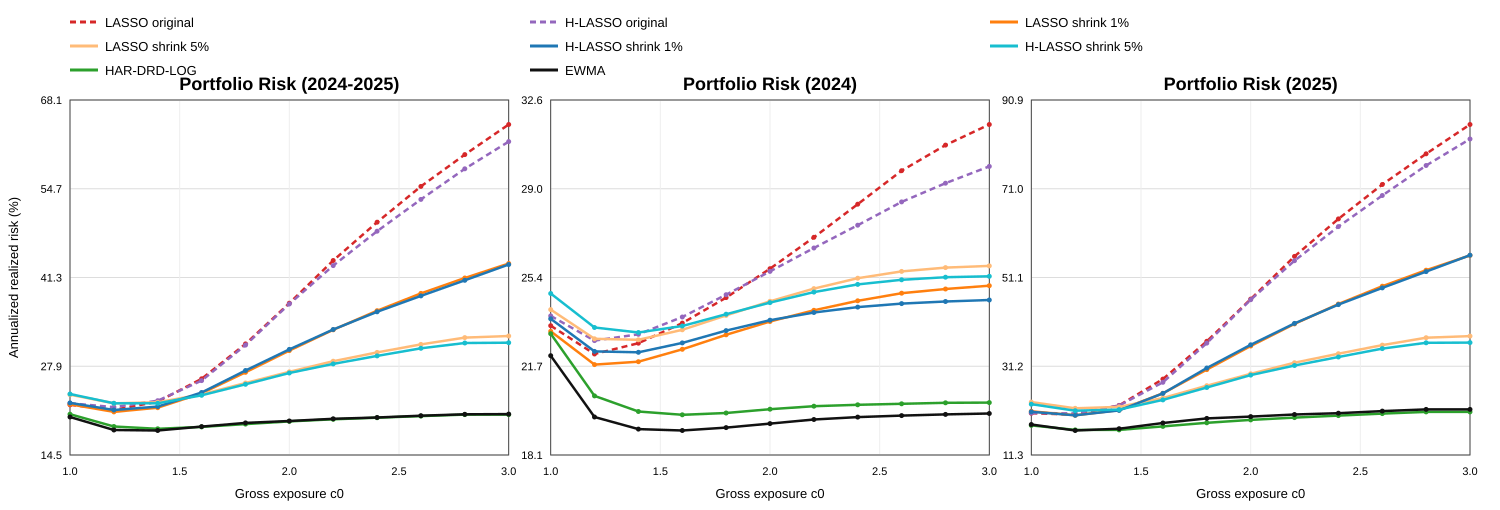

In [7]:
# Covariance preprocessing is shared across all 11 gross-exposure bounds.
returns_10min = np.load(PRVM_DIR / 'returns_10min_pred_crypto.npy', mmap_mode='r')
assert returns_10min.ndim == 3 and returns_10min.shape[0] == len(dates) and returns_10min.shape[2] == P
identity_p = np.eye(P)

def solve_portfolio_day(task):
    pred_day, jump_day, returns_day, delta = task
    pred_day = np.asarray(pred_day, dtype=np.float64)
    continuous = (1 - delta) * pred_day + delta * (np.trace(pred_day) / P) * identity_p
    covariance = 0.5 * (continuous + jump_day + continuous.T + jump_day.T)
    eig, vec = np.linalg.eigh(covariance)
    covariance = (vec * np.maximum(eig, 1e-8)) @ vec.T
    scale = np.mean(np.abs(covariance))
    covariance = covariance / (scale if scale >= 1e-20 else 1.0)
    intraday = np.nan_to_num(np.asarray(returns_day, dtype=np.float64), nan=0.0)
    daily_risks = np.empty(len(c0_values))
    fallback = np.zeros(len(c0_values), dtype=bool)
    weight = cp.Variable(P)
    auxiliary = cp.Variable(P)
    gross_limit = cp.Parameter(nonneg=True)
    problem = cp.Problem(
        cp.Minimize(cp.quad_form(weight, cp.psd_wrap(covariance))),
        [cp.sum(weight) == 1, auxiliary >= weight, auxiliary >= -weight, cp.sum(auxiliary) <= gross_limit],
    )
    for c0_index, c0 in enumerate(c0_values):
        gross_limit.value = float(c0)
        try:
            problem.solve(
                solver=cp.CLARABEL, canon_backend=cp.SCIPY_CANON_BACKEND,
                max_iter=5000, tol_feas=1e-8, tol_gap_abs=1e-8, tol_gap_rel=1e-8,
                warm_start=False, verbose=False,
            )
            if weight.value is None or not np.all(np.isfinite(weight.value)):
                raise ValueError('solver returned no finite weights')
            weights = np.asarray(weight.value).reshape(-1)
        except Exception:
            weights = np.ones(P) / P
            fallback[c0_index] = True
        daily_risks[c0_index] = np.sum((intraday @ weights) ** 2)
    return daily_risks, fallback

def evaluate_portfolio_risk(prediction, delta, jump_covariance, returns, workers=WORKERS):
    assert prediction.shape == jump_covariance.shape == (len(dates), P, P)
    risks = np.empty((len(c0_values), len(dates)), dtype=np.float64)
    fallback_count = 0
    tasks = ((prediction[t], jump_covariance[t], returns[t], delta) for t in range(len(dates)))
    with ThreadPoolExecutor(max_workers=workers) as executor:
        for day_index, (daily_risk, fallback) in enumerate(executor.map(solve_portfolio_day, tasks)):
            risks[:, day_index] = daily_risk
            fallback_count += int(fallback.sum())
            if (day_index + 1) % 100 == 0 or day_index + 1 == len(dates):
                print(f'  optimized {day_index + 1}/{len(dates)} days', flush=True)
    return risks, fallback_count

modified_specs = {
    'LASSO shrink 1%': ('LASSO', 0.01),
    'LASSO shrink 5%': ('LASSO', 0.05),
    'H-LASSO shrink 1%': ('H-LASSO', 0.01),
    'H-LASSO shrink 5%': ('H-LASSO', 0.05),
}
modified_risks = {}
modified_fallbacks = {}
for label, (base_model, delta) in modified_specs.items():
    print('Re-optimizing portfolios:', label, flush=True)
    modified_risks[label], modified_fallbacks[label] = evaluate_portfolio_risk(
        predictions[base_model], delta, jump_lag_psd, returns_10min,
    )

all_risks = {
    'LASSO original': baseline_risks['LASSO'],
    'H-LASSO original': baseline_risks['H-LASSO'],
    **modified_risks,
    'HAR-DRD-LOG': baseline_risks['HAR-DRD-LOG'],
    'EWMA': baseline_risks['EWMA'],
}
risk_curves = build_risk_curves(all_risks)
print('\nRisk improvement at c0 = 1, 2, 3:')
print(risk_improvement_table(risk_curves, {
    label: f'{base_model} original' for label, (base_model, _) in modified_specs.items()
}).to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nSolver fallback counts:', modified_fallbacks)
display(SVG(make_risk_svg(risk_curves, c0_values, {
    'LASSO original': '#d62728', 'LASSO shrink 1%': '#ff7f0e', 'LASSO shrink 5%': '#ffbb78',
    'H-LASSO original': '#9467bd', 'H-LASSO shrink 1%': '#1f77b4', 'H-LASSO shrink 5%': '#17becf',
    'HAR-DRD-LOG': '#2ca02c', 'EWMA': '#111111',
}, dashed=('LASSO original', 'H-LASSO original'))))

## Experiment 6 - Full-sample corrected Huber factor and portfolio risk
For all 730 OOS days, this experiment reuses the saved H-LASSO penalties, refits only the final idiosyncratic regressions, replaces the factor Huber threshold with `tau_F * scale`, reconstructs each covariance before PSD projection, and recalculates realized portfolio risk. No prediction or risk array is written to disk.

Full-sample H-LASSO reconstruction workers: 8


  reconstructed 100/730 days


  reconstructed 200/730 days


  reconstructed 300/730 days


  reconstructed 400/730 days


...

  optimized 500/730 days


  optimized 600/730 days


  optimized 700/730 days


  optimized 730/730 days



Full-sample portfolio-risk comparison at c0 = 1, 2, 3:
   period                        variant             comparison     c0  baseline_risk_pct  modified_risk_pct  relative_improvement_pct
2024-2025             H corrected factor             H original 1.0000            22.2783            22.0859                    0.8636
2024-2025             H corrected factor             H original 2.0000            37.2885            37.1463                    0.3815
2024-2025             H corrected factor             H original 3.0000            61.8336            61.9817                   -0.2394
2024-2025 H corrected factor + 1% shrink H original + 1% shrink 1.0000            22.3423            22.1334                    0.9352
2024-2025 H corrected factor + 1% shrink H original + 1% shrink 2.0000            30.4339            30.2576                    0.5792
2024-2025 H corrected factor + 1% shrink H original + 1% shrink 3.0000            43.2566            42.8582                    0.9211

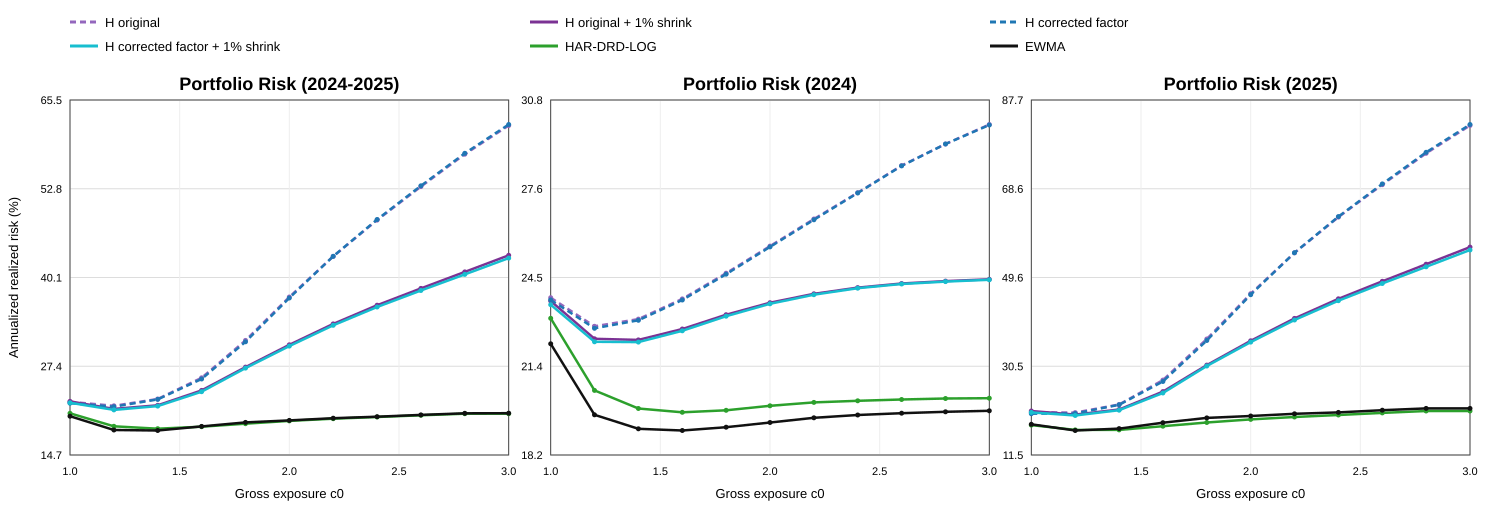

In [8]:
def prepare_full_huber_day(d):
    recent_mean = np.mean(np.asarray(poet_all[d - L:d], dtype=np.float64), axis=0)
    _, qf = np.linalg.eigh(recent_mean)
    qf = qf[:, ::-1][:, :R]
    history_poet = poet_all[d - N:d]
    ef = np.einsum('ik,tij,jk->tk', qf, history_poet, qf, optimize=True) / P
    average_idio_diagonal = np.mean(np.asarray(diag_sparse_all[d - L:d], dtype=np.float64), axis=0)
    idio_order = np.argsort(average_idio_diagonal)[::-1]
    ei = np.asarray(diag_sparse_all[d - N:d], dtype=np.float64)[:, idio_order]
    eh = np.concatenate([ef, ei], axis=1)
    target_factor = np.einsum('ik,ij,jk->k', qf, np.asarray(poet_all[d]), qf) / P
    idio_reference = np.median(eh[:, R:], axis=0)
    return qf, idio_order, ef, eh, target_factor, idio_reference

def full_huber_day_worker(day_index):
    d = N + day_index
    qf, idio_order, ef, eh, target_factor, idio_reference = prepare_full_huber_day(d)
    factor_current, limit_current, _, _, _ = fit_factor_huber(ef, corrected_epsilon=False)
    factor_corrected, limit_corrected, tau_f, factor_scale, corrected_epsilon = fit_factor_huber(ef, corrected_epsilon=True)
    idio_scores, _, limit_idio = fit_h_idio_only(eh, day_index)
    idio_diagonal = np.empty(P, dtype=np.float64)
    idio_diagonal[idio_order] = idio_scores
    idio_reference_diagonal = np.empty(P, dtype=np.float64)
    idio_reference_diagonal[idio_order] = idio_reference
    factor_matrix_current = (qf * (P * factor_current)) @ qf.T
    factor_matrix_corrected = (qf * (P * factor_corrected)) @ qf.T
    raw_current = factor_matrix_current + np.diag(idio_diagonal)
    raw_corrected = factor_matrix_corrected + np.diag(idio_diagonal)
    projected_current, raw_eig_current, floor_current = project_portfolio(raw_current)
    projected_corrected, raw_eig_corrected, floor_corrected = project_portfolio(raw_corrected)
    saved = np.asarray(predictions['H-LASSO'][day_index])
    reproduction_error = np.linalg.norm(projected_current - saved) / np.linalg.norm(saved)
    assert np.isfinite(reproduction_error) and reproduction_error < REPRODUCTION_RTOL, (day_index, reproduction_error)
    diagnostics = {
        'factor_loss_current': np.sum((factor_current - target_factor) ** 2),
        'factor_loss_corrected': np.sum((factor_corrected - target_factor) ** 2),
        'negative_idio': int(np.sum(idio_scores < 0)),
        'raw_below_floor_current': int(np.sum(raw_eig_current < floor_current)),
        'raw_below_floor_corrected': int(np.sum(raw_eig_corrected < floor_corrected)),
        'raw_min_eigen_corrected': raw_eig_corrected[0],
        'reproduction_error': reproduction_error,
        'max_iter_hits': limit_current + limit_corrected + limit_idio,
        'tau_F': tau_f, 'factor_scale': factor_scale, 'corrected_epsilon': corrected_epsilon,
    }
    return day_index, projected_corrected, diagnostics, qf, factor_corrected, idio_diagonal, idio_reference_diagonal

corrected_h_predictions = np.empty(predictions['H-LASSO'].shape, dtype=np.float64)
corrected_h_factor_loadings = np.empty((len(dates), P, R), dtype=np.float64)
corrected_h_factor_scores = np.empty((len(dates), R), dtype=np.float64)
raw_h_idio_diagonals = np.empty((len(dates), P), dtype=np.float64)
idio_reference_diagonals = np.empty((len(dates), P), dtype=np.float64)
full_huber_diagnostics = [None] * len(dates)
huber_workers = WORKERS
print('Full-sample H-LASSO reconstruction workers:', huber_workers)
with ThreadPoolExecutor(max_workers=huber_workers) as executor:
    for completed, result in enumerate(executor.map(full_huber_day_worker, range(len(dates))), start=1):
        day_index, corrected_matrix, diagnostics, qf, factor_scores, idio_diagonal, idio_reference = result
        corrected_h_predictions[day_index] = corrected_matrix
        corrected_h_factor_loadings[day_index] = qf
        corrected_h_factor_scores[day_index] = factor_scores
        raw_h_idio_diagonals[day_index] = idio_diagonal
        idio_reference_diagonals[day_index] = idio_reference
        full_huber_diagnostics[day_index] = diagnostics
        if completed % 100 == 0 or completed == len(dates):
            print(f'  reconstructed {completed}/{len(dates)} days', flush=True)

diagnostic_df = pd.DataFrame(full_huber_diagnostics)
factor_comparison_rows = []
for period, mask in period_masks.items():
    current = diagnostic_df.loc[mask, 'factor_loss_current'].to_numpy()
    corrected = diagnostic_df.loc[mask, 'factor_loss_corrected'].to_numpy()
    factor_comparison_rows.append({
        'period': period, 'current_mean': current.mean(), 'corrected_mean': corrected.mean(),
        'mean_improvement_pct': 100 * (current.mean() - corrected.mean()) / current.mean(),
        'current_median': np.median(current), 'corrected_median': np.median(corrected),
        'median_improvement_pct': 100 * (np.median(current) - np.median(corrected)) / np.median(current),
        'current_q95': np.quantile(current, 0.95), 'corrected_q95': np.quantile(corrected, 0.95),
        'q95_improvement_pct': 100 * (np.quantile(current, 0.95) - np.quantile(corrected, 0.95)) / np.quantile(current, 0.95),
    })
print('\nFull-sample factor-score comparison:')
print(pd.DataFrame(factor_comparison_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))

corrected_mspe = frobenius_loss_series(corrected_h_predictions, true_poet)
corrected_qlike = qlike_series(corrected_h_predictions)
matrix_comparison_rows = []
for period, mask in period_masks.items():
    original_mspe = loss_series['H-LASSO'][mask].mean()
    new_mspe = corrected_mspe[mask].mean()
    original_qlike = qlike_daily['H-LASSO'][mask].mean() * 1e-3
    new_qlike = corrected_qlike[mask].mean() * 1e-3
    matrix_comparison_rows.append({
        'period': period, 'original_MSPE': original_mspe, 'corrected_MSPE': new_mspe,
        'MSPE_improvement_pct': 100 * (original_mspe - new_mspe) / original_mspe,
        'original_QLIKE_x1e-3': original_qlike, 'corrected_QLIKE_x1e-3': new_qlike,
    })
print('\nCorrected continuous-covariance forecast comparison:')
print(pd.DataFrame(matrix_comparison_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))
print('\nReconstruction/internals:')
print('maximum relative reproduction error:', diagnostic_df['reproduction_error'].max())
print('mean relative reproduction error:', diagnostic_df['reproduction_error'].mean())
print('total max-iteration hits:', int(diagnostic_df['max_iter_hits'].sum()))
print('days with negative idio scores:', int((diagnostic_df['negative_idio'] > 0).sum()))
print('mean negative idio-score count:', diagnostic_df['negative_idio'].mean())

# Reuse Experiment 5's identical original-H + 1% result (8,030 solves avoided).
full_huber_modified_risks = {'H original + 1% shrink': modified_risks['H-LASSO shrink 1%']}
full_huber_fallbacks = {'H original + 1% shrink': modified_fallbacks['H-LASSO shrink 1%']}
for label, delta in [('H corrected factor', 0.0), ('H corrected factor + 1% shrink', 0.01)]:
    print('Re-optimizing full-sample portfolio:', label, flush=True)
    full_huber_modified_risks[label], full_huber_fallbacks[label] = evaluate_portfolio_risk(
        corrected_h_predictions, delta, jump_lag_psd, returns_10min,
    )

full_huber_all_risks = {
    'H original': baseline_risks['H-LASSO'],
    **full_huber_modified_risks,
    'HAR-DRD-LOG': baseline_risks['HAR-DRD-LOG'],
    'EWMA': baseline_risks['EWMA'],
}
full_huber_risk_curves = build_risk_curves(full_huber_all_risks)
print('\nFull-sample portfolio-risk comparison at c0 = 1, 2, 3:')
print(risk_improvement_table(full_huber_risk_curves, {
    'H corrected factor': 'H original',
    'H corrected factor + 1% shrink': 'H original + 1% shrink',
}).to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nSolver fallback counts (original + 1% reused):', full_huber_fallbacks)
display(SVG(make_risk_svg(full_huber_risk_curves, c0_values, {
    'H original': '#9467bd', 'H original + 1% shrink': '#7b3294',
    'H corrected factor': '#1f77b4', 'H corrected factor + 1% shrink': '#17becf',
    'HAR-DRD-LOG': '#2ca02c', 'EWMA': '#111111',
}, dashed=('H original', 'H corrected factor'))))

## Experiment 7 - Positive idiosyncratic-score treatments
This experiment holds the corrected factor Huber forecast, saved H-LASSO penalties, PSD projection, lagged jump covariance, and 1% covariance shrinkage fixed. It compares the current raw idiosyncratic forecast with hard zero clipping, a positive floor equal to 1% of each component's rolling training-window median, and a softplus transform using the same 1% ex-ante scale. All arrays remain in memory and only tables and an SVG are embedded below.

Idiosyncratic-score treatment diagnostics:
   period           variant  idio_score_MSE  negative_output_count  adjusted_entry_ratio  mean_abs_adjustment
2024-2025  Current raw idio   3.3092165e-06                   1712                     0                    0
     2024  Current raw idio   3.4448972e-06                    523                     0                    0
     2025  Current raw idio   3.1735359e-06                   1189                     0                    0
2024-2025         Hard zero   3.3031271e-06                      0           0.011726027        2.8567151e-06
     2024         Hard zero   3.4422406e-06                      0          0.0071643836        1.3234991e-06
     2025         Hard zero   3.1640136e-06                      0           0.016287671        4.3899312e-06
2024-2025 Adaptive floor 1%   3.3030877e-06                      0           0.011958904         2.892267e-06
     2024 Adaptive floor 1%   3.4422207e-06                      0          0

Re-optimizing portfolio with common 1% covariance shrinkage: Hard zero


  optimized 100/730 days


  optimized 200/730 days


  optimized 300/730 days


...

  optimized 500/730 days


  optimized 600/730 days


  optimized 700/730 days


  optimized 730/730 days



Continuous-covariance comparison before common 1% shrinkage:
   period           variant  MSPE_mean  MSPE_median   MSPE_q95  QLIKE_x1e-3  floor_hit_day_ratio  floor_count_mean  raw_min_eigen_median
2024-2025  Current raw idio 0.13128346   0.01445051 0.29924405  0.058679976           0.80273973         2.3082192        -0.00015460592
     2024  Current raw idio  0.1114974  0.014712737 0.30770078  -0.52479341           0.70684932         1.3945205        -5.5401091e-05
     2025  Current raw idio 0.15106952  0.014429094  0.2489419   0.64215336           0.89863014         3.2219178        -0.00031544363
2024-2025         Hard zero 0.13128323  0.014451036 0.29924413   -0.2760151           0.61506849         1.3986301         1.9903837e-08
     2024         Hard zero 0.11149725  0.014712737 0.30769979  -0.77990848           0.48767123        0.72328767         3.2547925e-07
     2025         Hard zero 0.15106921  0.014429257 0.24894453   0.22787828           0.74246575         2.0739726  

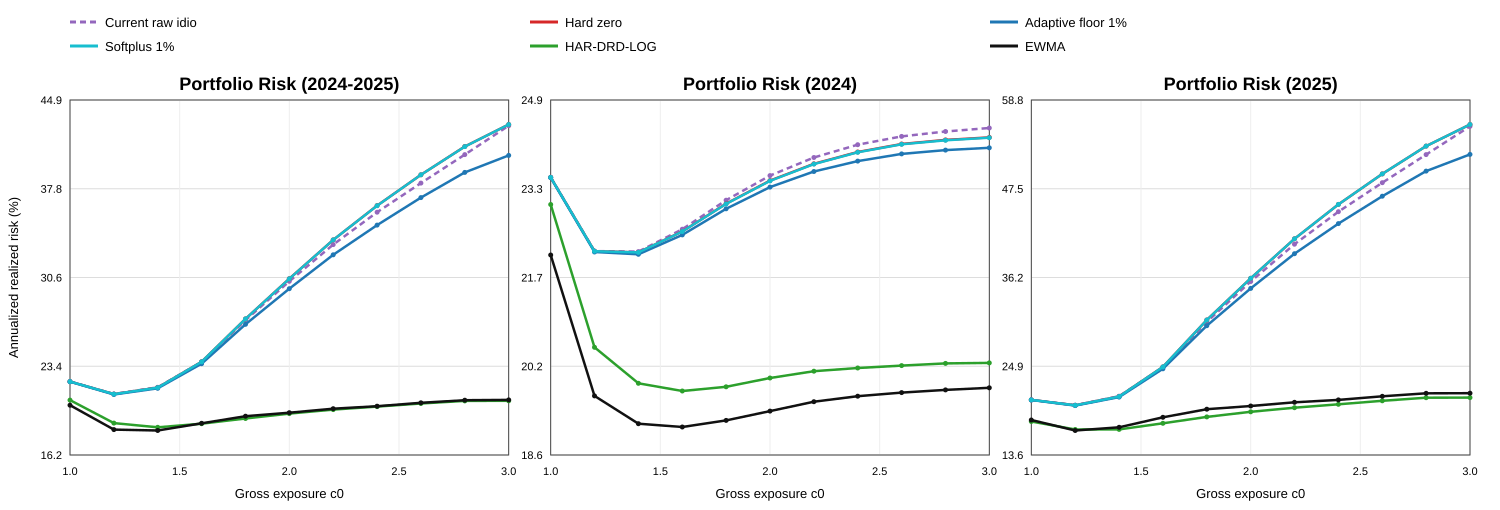

In [9]:
idio_methods = {
    'Current raw idio': 'raw',
    'Hard zero': 'hard_zero',
    'Adaptive floor 1%': 'floor_1pct',
    'Softplus 1%': 'softplus_1pct',
}

def transform_idio_scores(raw_scores, reference_scores, method):
    raw_scores = np.asarray(raw_scores, dtype=np.float64)
    reference_scores = np.maximum(np.asarray(reference_scores, dtype=np.float64), 1e-12)
    if method == 'raw':
        return raw_scores.copy()
    if method == 'hard_zero':
        return np.maximum(raw_scores, 0.0)
    local_scale = 0.01 * reference_scores
    if method == 'floor_1pct':
        return np.maximum(raw_scores, local_scale)
    if method == 'softplus_1pct':
        return local_scale * np.logaddexp(0.0, raw_scores / local_scale)
    raise ValueError(f'Unknown idio treatment: {method}')

target_idio_diagonals = np.asarray(diag_sparse_all[N:], dtype=np.float64)
idio_score_rows = []
for label, method in idio_methods.items():
    transformed = transform_idio_scores(raw_h_idio_diagonals, idio_reference_diagonals, method)
    daily_score_mse = np.mean((transformed - target_idio_diagonals) ** 2, axis=1)
    daily_abs_adjustment = np.mean(np.abs(transformed - raw_h_idio_diagonals), axis=1)
    daily_adjusted_ratio = np.mean(np.abs(transformed - raw_h_idio_diagonals) > 1e-15, axis=1)
    for period, mask in period_masks.items():
        idio_score_rows.append({
            'period': period, 'variant': label,
            'idio_score_MSE': daily_score_mse[mask].mean(),
            'negative_output_count': int(np.sum(transformed[mask] < 0)),
            'adjusted_entry_ratio': daily_adjusted_ratio[mask].mean(),
            'mean_abs_adjustment': daily_abs_adjustment[mask].mean(),
        })
print('Idiosyncratic-score treatment diagnostics:')
print(pd.DataFrame(idio_score_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))

def build_idio_treated_predictions(method):
    treated_all = transform_idio_scores(raw_h_idio_diagonals, idio_reference_diagonals, method)
    prediction_cube = np.empty(predictions['H-LASSO'].shape, dtype=np.float64)
    raw_floor_counts = np.empty(len(dates), dtype=np.int64)
    raw_min_eigenvalues = np.empty(len(dates), dtype=np.float64)
    for day_index in range(len(dates)):
        qf = corrected_h_factor_loadings[day_index]
        factor_scores = corrected_h_factor_scores[day_index]
        factor_matrix = (qf * (P * factor_scores)) @ qf.T
        raw_matrix = factor_matrix + np.diag(treated_all[day_index])
        projected, raw_eig, floor = project_portfolio(raw_matrix)
        prediction_cube[day_index] = projected
        raw_floor_counts[day_index] = np.sum(raw_eig < floor)
        raw_min_eigenvalues[day_index] = raw_eig[0]
    return prediction_cube, raw_floor_counts, raw_min_eigenvalues

def append_matrix_summary(rows, label, daily_mspe, daily_qlike, floor_counts, min_eigenvalues):
    for period, mask in period_masks.items():
        rows.append({
            'period': period, 'variant': label,
            'MSPE_mean': daily_mspe[mask].mean(),
            'MSPE_median': np.median(daily_mspe[mask]),
            'MSPE_q95': np.quantile(daily_mspe[mask], 0.95),
            'QLIKE_x1e-3': daily_qlike[mask].mean() * 1e-3,
            'floor_hit_day_ratio': np.mean(floor_counts[mask] > 0),
            'floor_count_mean': floor_counts[mask].mean(),
            'raw_min_eigen_median': np.median(min_eigenvalues[mask]),
        })

idio_matrix_rows = []
idio_daily_matrix_metrics = {}
baseline_floor_counts = diagnostic_df['raw_below_floor_corrected'].to_numpy(dtype=np.int64)
baseline_min_eigenvalues = diagnostic_df['raw_min_eigen_corrected'].to_numpy()
append_matrix_summary(
    idio_matrix_rows, 'Current raw idio', corrected_mspe, corrected_qlike,
    baseline_floor_counts, baseline_min_eigenvalues,
)
idio_daily_matrix_metrics['Current raw idio'] = (corrected_mspe, corrected_qlike, baseline_floor_counts)

idio_modified_risks = {}
idio_fallback_rows = []
for label, method in list(idio_methods.items())[1:]:
    print(f'\nBuilding full-sample covariance forecasts: {label}')
    treated_prediction, floor_counts, min_eigenvalues = build_idio_treated_predictions(method)
    daily_mspe = frobenius_loss_series(treated_prediction, true_poet)
    daily_qlike = qlike_series(treated_prediction)
    append_matrix_summary(idio_matrix_rows, label, daily_mspe, daily_qlike, floor_counts, min_eigenvalues)
    idio_daily_matrix_metrics[label] = (daily_mspe, daily_qlike, floor_counts)
    print(f'Re-optimizing portfolio with common 1% covariance shrinkage: {label}')
    risk, fallback_count = evaluate_portfolio_risk(
        treated_prediction, 0.01, jump_lag_psd, returns_10min,
    )
    idio_modified_risks[label] = risk
    idio_fallback_rows.append({
        'variant': label, 'fallback_count': fallback_count,
        'fallback_ratio': fallback_count / risk.size,
    })
    del treated_prediction

print('\nContinuous-covariance comparison before common 1% shrinkage:')
print(pd.DataFrame(idio_matrix_rows).to_string(index=False, float_format=lambda x: f'{x:.8g}'))

event_idio_rows = []
for date_string in ['2025-10-10', '2025-10-11', str(dates.iloc[floor_peak_idx].date())]:
    day_index = date_indices[date_string]
    for label, (daily_mspe, daily_qlike, floor_counts) in idio_daily_matrix_metrics.items():
        event_idio_rows.append({
            'date': date_string, 'variant': label,
            'MSPE': daily_mspe[day_index], 'QLIKE_x1e-3': daily_qlike[day_index] * 1e-3,
            'raw_floor_count': floor_counts[day_index],
        })
print('\nSelected-event covariance comparison:')
print(pd.DataFrame(event_idio_rows).drop_duplicates().to_string(index=False, float_format=lambda x: f'{x:.8g}'))

idio_baseline_risk = full_huber_modified_risks['H corrected factor + 1% shrink']
idio_all_risks = {
    'Current raw idio': idio_baseline_risk,
    **idio_modified_risks,
    'HAR-DRD-LOG': baseline_risks['HAR-DRD-LOG'],
    'EWMA': baseline_risks['EWMA'],
}
idio_risk_curves = build_risk_curves(idio_all_risks)
print('\nPortfolio risk with corrected factor and common 1% covariance shrinkage:')
print(risk_improvement_table(idio_risk_curves, {
    label: 'Current raw idio' for label in list(idio_methods)[1:]
}).to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nSolver fallback diagnostics:')
print(pd.DataFrame(idio_fallback_rows).to_string(index=False, float_format=lambda x: f'{x:.6g}'))

display(SVG(make_risk_svg(idio_risk_curves, c0_values, {
    'Current raw idio': '#9467bd', 'Hard zero': '#d62728',
    'Adaptive floor 1%': '#1f77b4', 'Softplus 1%': '#17becf',
    'HAR-DRD-LOG': '#2ca02c', 'EWMA': '#111111',
}, dashed=('Current raw idio',))))

## Final validation
Check reconstruction fidelity, finite outputs, and portfolio solver fallbacks. Input immutability is verified externally when running this notebook; no recursive filesystem snapshots are part of the research workflow. Results remain in memory so completed experiment cells can be rerun. Restart the kernel to release the retained arrays.

In [10]:
assert diagnostic_df['reproduction_error'].max() < REPRODUCTION_RTOL
for label, risk in {**all_risks, **full_huber_all_risks, **idio_all_risks}.items():
    assert risk.shape == (len(c0_values), len(dates)) and np.all(np.isfinite(risk)), label
    assert np.all(risk >= 0), label
assert np.all(np.isfinite(corrected_mspe)) and np.all(np.isfinite(corrected_qlike))
assert all(count == 0 for count in modified_fallbacks.values()), modified_fallbacks
assert all(count == 0 for count in full_huber_fallbacks.values()), full_huber_fallbacks
assert all(row['fallback_count'] == 0 for row in idio_fallback_rows), idio_fallback_rows
assert full_huber_modified_risks['H original + 1% shrink'] is modified_risks['H-LASSO shrink 1%']
print('PASS: finite results, original covariance reconstruction within tolerance, no solver fallbacks, and identical baseline reused.')

PASS: finite results, original covariance reconstruction within tolerance, no solver fallbacks, and identical baseline reused.
